In [1]:
from google.colab import files
uploaded = files.upload()

Saving Advertising.csv to Advertising.csv


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

plt.style.use('ggplot')

In [3]:
df = pd.read_csv("Advertising.csv")

df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [4]:
print(df.shape)

df.info()

df.describe()

(200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [5]:
df.isnull().sum()

,0
Unnamed: 0,0
TV,0
Radio,0
Newspaper,0
Sales,0


In [6]:
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)

df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [7]:
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)

df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


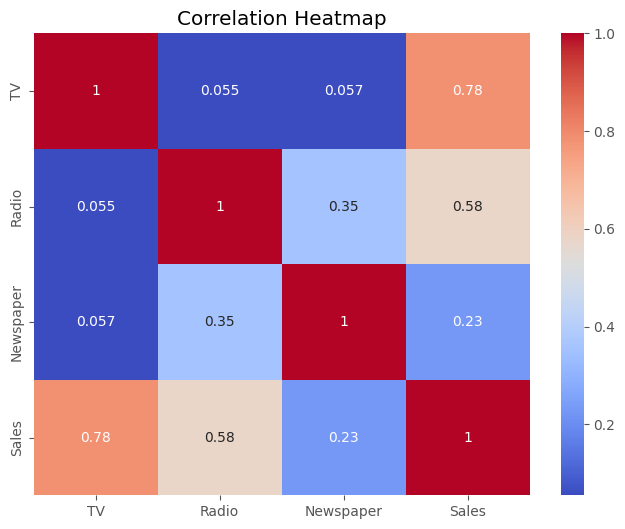

In [8]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

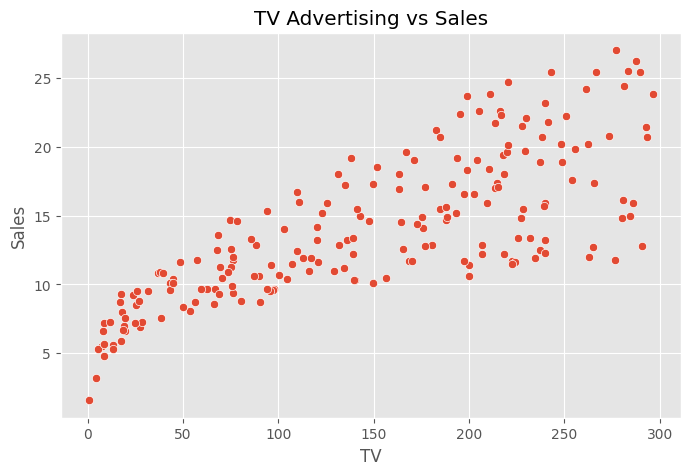

In [9]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='TV',
    y='Sales',
    data=df
)

plt.title("TV Advertising vs Sales")

plt.show()

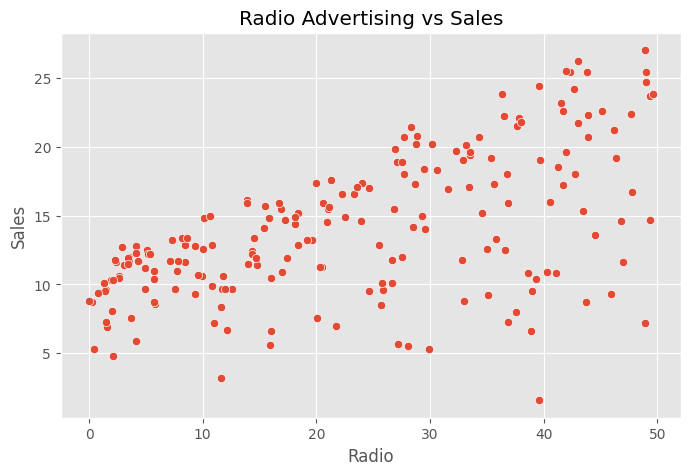

In [10]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Radio',
    y='Sales',
    data=df
)

plt.title("Radio Advertising vs Sales")

plt.show()

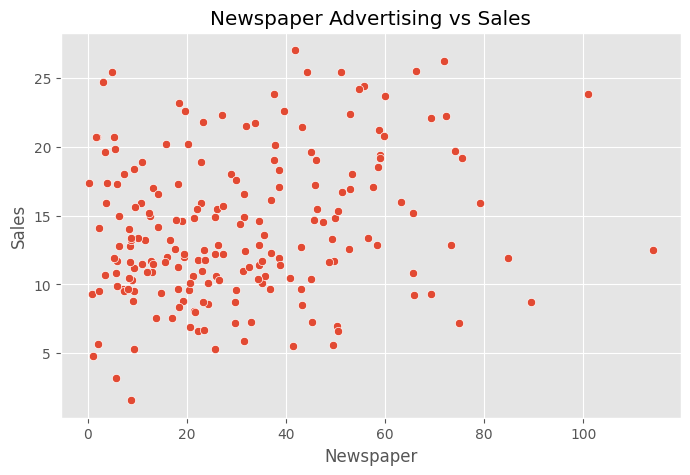

In [11]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Newspaper',
    y='Sales',
    data=df
)

plt.title("Newspaper Advertising vs Sales")

plt.show()

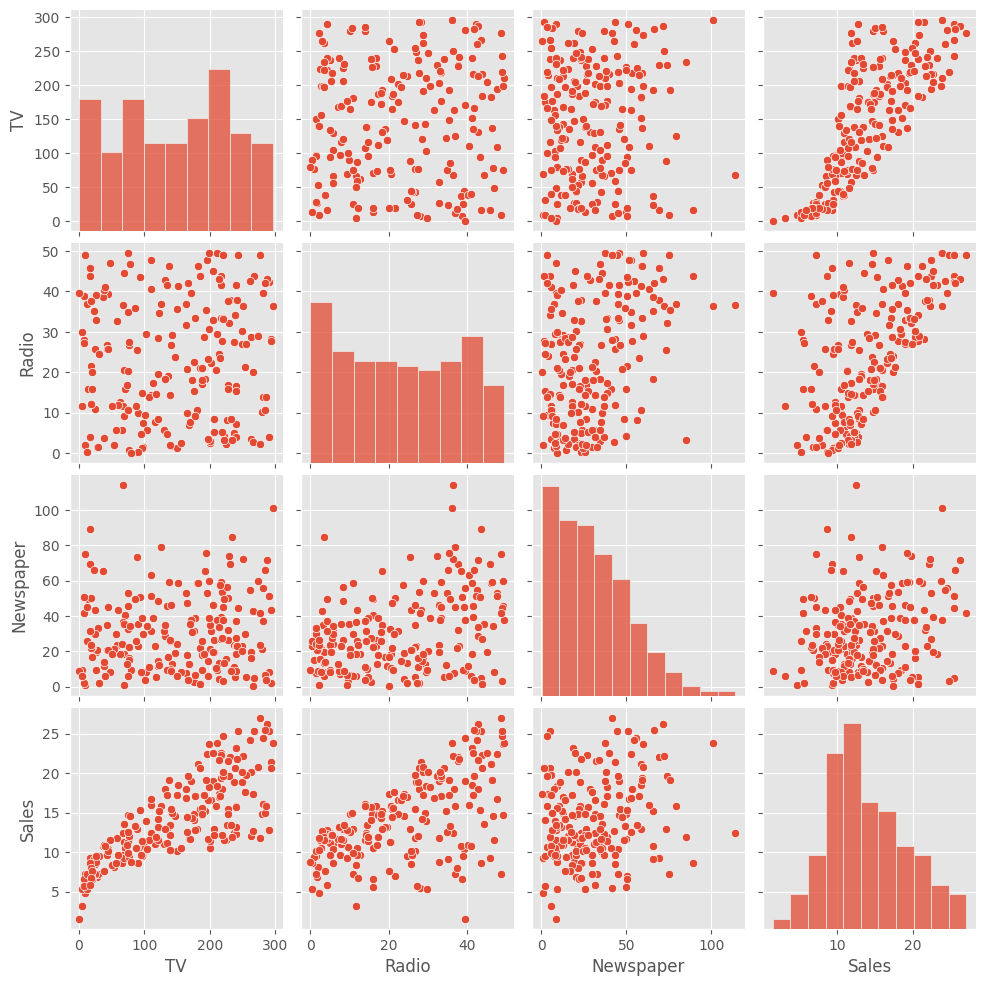

In [12]:
sns.pairplot(df)

plt.show()

In [13]:
X = df[['TV','Radio','Newspaper']]

y = df['Sales']

In [14]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
model = LinearRegression()

model.fit(X_train,y_train)

LinearRegression()

In [16]:
y_pred = model.predict(X_test)

In [17]:
print("MAE :", mean_absolute_error(y_test,y_pred))

print("MSE :", mean_squared_error(y_test,y_pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test,y_pred)))

print("R2 Score :", r2_score(y_test,y_pred))

MAE : 1.4607567168117603
MSE : 3.1740973539761033
RMSE : 1.78159966153345
R2 Score : 0.899438024100912


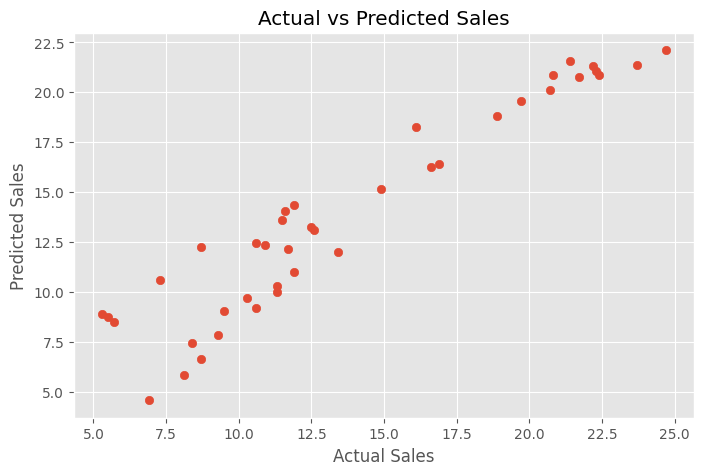

In [18]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()

In [19]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Coefficient':model.coef_
})

importance.sort_values(
    by='Coefficient',
    ascending=False,
    inplace=True
)

print(importance)

     Feature  Coefficient
1      Radio     0.189195
0         TV     0.044730
2  Newspaper     0.002761


In [20]:
sample = [[230.1,37.8,69.2]]

prediction = model.predict(sample)

print("Predicted Sales =", prediction[0])

Predicted Sales = 20.613971470156297


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [21]:
import joblib

joblib.dump(
    model,
    "sales_prediction_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully
